In [1]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [24]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import os
from os.path import abspath, dirname

In [3]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [22]:
dycore = 'CAM-SE'
res = 'se_ne60'
test_name_start = 'cam_6_4_100'
lev_no = 'ztop20km_L57'
extra_name = 'tau_1_10'

case = f'{test_name_start}_{res}_{lev_no}'

nc_rot = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name}.nc'
nc_omega0 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name}.nc'


NameError: name '__file__' is not defined

In [5]:
run_base = "/glade/derecho/scratch/timand/"

run_path_omega0 = run_base + case + '/run/' + nc_omega0
run_path_rot = run_base + case + '/run/' + nc_rot

nc_omega0 = Dataset(run_path_omega0)
nc_rot = Dataset(run_path_rot)

In [6]:
time = nc_omega0['time'][:]
lat = nc_omega0['lat'][:] 
lon = nc_omega0['lon'][:] 

In [7]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

lat_crop_up = 40.
lat_cent_down = -40.
lat_ticks = np.linspace(-40,40,5)

lon_crop_left = 160.
lon_crop_right = 260.
lon_ticks = np.linspace(160, 260, 6)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

In [8]:
# Time indices
t_idxs = np.array([10,20,30])

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [9]:
# Interpolations of U and T

U_field_vals1_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals2_omega0 = z_interp(nc_omega0['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals3_omega0 = z_interp(nc_omega0['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_omega0['U'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

U_field_vals1_rot = z_interp(nc_rot['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals2_rot = z_interp(nc_rot['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals3_rot = z_interp(nc_rot['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_rot['U'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_field_vals1_omega0 = z_interp(nc_omega0['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals2_omega0 = z_interp(nc_omega0['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals3_omega0 = z_interp(nc_omega0['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_omega0['T'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_field_vals1_rot = z_interp(nc_rot['Z3'][t_idxs[0], :, lat_inds, lon_inds], nc_rot['T'][t_idxs[0], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals2_rot = z_interp(nc_rot['Z3'][t_idxs[1], :, lat_inds, lon_inds], nc_rot['T'][t_idxs[1], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals3_rot = z_interp(nc_rot['Z3'][t_idxs[2], :, lat_inds, lon_inds], nc_rot['T'][t_idxs[2], :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [10]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1_omega0  = (U_field_vals1_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2_omega0  = (U_field_vals2_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3_omega0  = (U_field_vals3_omega0  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals1_rot  = (U_field_vals1_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2_rot  = (U_field_vals2_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3_rot  = (U_field_vals3_rot  - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
T_field_vals1_omega0 = T_field_vals1_omega0 - T0
T_field_vals2_omega0 = T_field_vals2_omega0 - T0
T_field_vals3_omega0 = T_field_vals3_omega0 - T0
T_field_vals1_rot = T_field_vals1_rot - T0
T_field_vals2_rot = T_field_vals2_rot - T0
T_field_vals3_rot = T_field_vals3_rot - T0

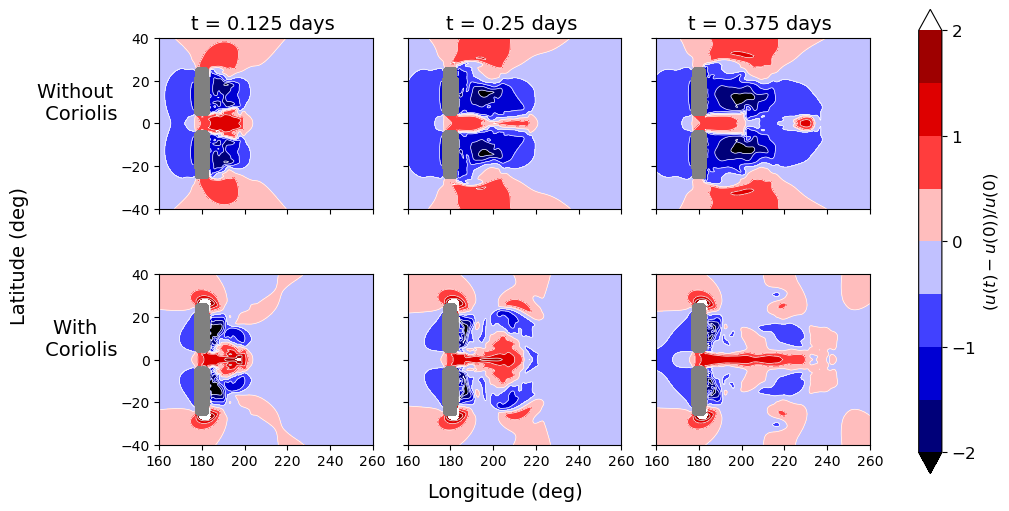

In [28]:
# U over time, both omega0 and with rot
U_cmap = matplotlib.cm.seismic
#U_cmap = matplotlib.cm.RdYlBu_r
U_cmap.set_under('k')
U_cmap.set_over('white')

fig, axes = plt.subplots(2,3, sharey=True, sharex=True, figsize = (10,5), layout="constrained")
(ax1, ax2, ax3), (ax4,ax5,ax6) = axes

U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)

plot1 = ax1.contourf(LON, LAT, U_field_vals1_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, U_field_vals3_omega0, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, U_field_vals1_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot5 = ax5.contourf(LON, LAT, U_field_vals2_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot6 = ax6.contourf(LON, LAT, U_field_vals3_rot, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax3.contour(LON, LAT, U_field_vals3_omega0, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax4.contour(LON, LAT, U_field_vals1_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax5.contour(LON, LAT, U_field_vals2_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax6.contour(LON, LAT, U_field_vals3_rot, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

plt.ylim([-40,40])

ax1.set_ylabel('Without \n Coriolis', rotation=0, labelpad=30, size=14)
ax4.set_ylabel('With \n Coriolis', rotation=0, labelpad=30, size=14)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')
ax5.set_aspect('equal')
ax6.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")
ax5.set_facecolor("grey")
ax6.set_facecolor("grey")

cb = plt.colorbar(plot6, ax=axes, ticks = tick_range, fraction=0.2)
cb.set_label(label='$(u(t) - u(0))/u(0)$', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f't = {time[t_idxs[0]]} days ', size=label_size)
ax2.set_title(f't = {time[t_idxs[1]]} days ', size=label_size)
ax3.set_title(f't = {time[t_idxs[2]]} days ', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
plt.savefig('figures/gap_U_over_time.png')

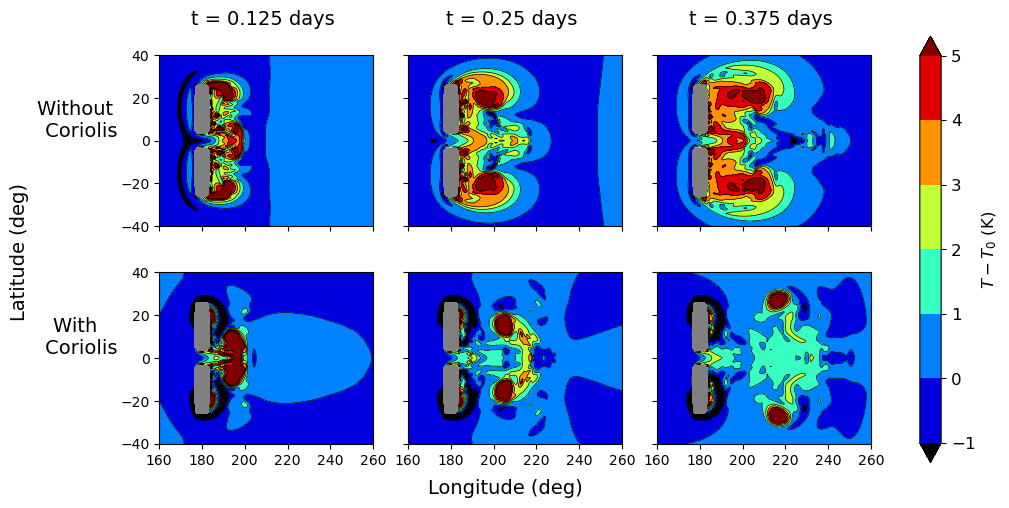

In [29]:
# T over time, both omega0 and with rot
T_cmap = copy.copy(matplotlib.cm.jet)
T_cmap.set_under('k')

fig, axes = plt.subplots(2,3, sharey=True, sharex=True, figsize = (10,5), layout="constrained")
(ax1, ax2, ax3), (ax4,ax5,ax6) = axes

T_conts = np.linspace(-1, 5, 7)
norm = colors.Normalize(vmin=-1, vmax=5)
tick_range = np.linspace(-1, 5, 7)

plot1 = ax1.contourf(LON, LAT, T_field_vals1_omega0, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2_omega0, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, T_field_vals3_omega0, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, T_field_vals1_rot, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot5 = ax5.contourf(LON, LAT, T_field_vals2_rot, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot6 = ax6.contourf(LON, LAT, T_field_vals3_rot, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, T_field_vals1_omega0, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, T_field_vals2_omega0, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax3.contour(LON, LAT, T_field_vals3_omega0, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax4.contour(LON, LAT, T_field_vals1_rot, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax5.contour(LON, LAT, T_field_vals2_rot, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax6.contour(LON, LAT, T_field_vals3_rot, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')

plt.ylim([-40,40])
ax1.set_ylabel('Without \n Coriolis', rotation=0, labelpad=30, size=14)
ax4.set_ylabel('With \n Coriolis', rotation=0, labelpad=30, size=14)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')
ax5.set_aspect('equal')
ax6.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")
ax3.set_facecolor("grey")
ax4.set_facecolor("grey")
ax5.set_facecolor("grey")
ax6.set_facecolor("grey")

cb = plt.colorbar(plot6, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f't = {time[t_idxs[0]]} days ', size=label_size)
ax2.set_title(f't = {time[t_idxs[1]]} days ', size=label_size)
ax3.set_title(f't = {time[t_idxs[2]]} days ', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
plt.savefig('figures/gap_T_over_time.png')